In [20]:
import earthaccess
import geopandas as gpd
import lonboard
import odc.stac
import pyproj
import pystac
import pystac_client
from shapely.geometry import box
from shapely.ops import transform

In [2]:
HLS_COLLECTION_IDS = ["HLSL30_2.0", "HLSS30_2.0"]

URL_PREFIX = "https://data.lpdaac.earthdatacloud.nasa.gov/"

In [3]:
auth = earthaccess.login(strategy="interactive", persist=True)
s3_creds = auth.get_s3_credentials("LPDAAC")

odc.stac.configure_rio(
    cloud_defaults=True,
    aws=dict(
        aws_access_key_id=s3_creds["accessKeyId"],
        aws_secret_access_key=s3_creds["secretAccessKey"],
        aws_session_token=s3_creds["sessionToken"],
        region_name="us-west-2",
    )
)

In [15]:
CRS_STRING = "epsg:5070"
EPSG = pyproj.CRS.from_string(CRS_STRING).to_epsg()

START_DATE = "2024-01-01"
END_DATE = "2025-12-31"

def convert_to_s3_uri(url: str) -> str:
    return url.replace(
        URL_PREFIX,
        "s3://"
    )

# 100 km bounding box
xmin, ymin = 250000, 2750000
bbox = (xmin, ymin, xmin + 100000, ymin + 100000)
aoi = box(*bbox)

# STAC items store bounding box info in epsg:4326
transformer_4326 = pyproj.Transformer.from_crs(
    crs_from=CRS_STRING,
    crs_to="epsg:4326",
    always_xy=True,
)

bbox_4326 = transform(transformer_4326.transform, aoi).bounds

In [19]:
ecs_gpkg_dsn = "/vsizip/vsicurl/https://resources.gisdata.mn.gov/pub/gdrs/data/pub/us_mn_state_dnr/biota_dnr_forestry_npc_obs/gpkg_biota_dnr_forestry_npc_obs.zip/biota_dnr_forestry_npc_obs.gpkg"

gdf = gpd.read_file(ecs_gpkg_dsn, layer="NPC_TRANSECTS")
gdf

/srv/conda/envs/notebook/lib/python3.12/site-packages/pyogrio/raw.py:196: RuntimeWarning: Non-conformant content for record 1 in column DATE_COLLECTED, 2017-07-17T05:00:00.0Z, successfully parsed
  return ogr_read(


,NPC_CATEGORY_CODE,NPC_SYSTEM,NPC_CATEGORY_NAME,NPC_CATEGORY_LEVEL,GROWTH_STAGE_CODE,COMMENTS,DATE_COLLECTED,OPERABILITY_RATING_CODE,ACRES_REPRESENTED,EXPERT_REVIEW_REQD_FLAG,...,DATE_ENTERED,NPC_CATEGORY_ID,Worksheet,OBSERVER1,OBSERVER2,OBSERVER3,PLOT_STATUS,NPC_AREA_ID,NPC_TRANSECT_ID,geometry
0,MHc26,MH,CENTRAL DRY-MESIC OAK-ASPEN FOREST,NPC Class,T1,None,2017-07-17 05:00:00+00:00,Wf > Sd > Fd > W > S,10.0,0,...,2017-07-20 18:15:09+00:00,104,http://arcgis.intranet.mndnr.dnr.state.mn.us/N...,"Walker, Renae","Lang, Benjamin","Tjader, Harvey",None,None,{09647E4A-BB4B-48D7-981C-47E4B1D3C540},POINT (348143 5248797)
1,FDc34,FD,CENTRAL DRY-MESIC PINE-HARDWOOD FOREST,NPC Class,T1,None,2017-07-18 05:00:00+00:00,All,0.0,0,...,2017-07-20 18:31:37+00:00,73,http://arcgis.intranet.mndnr.dnr.state.mn.us/N...,"Tjader, Harvey","Walker, Renae",None,None,None,{01753A12-0DAB-4141-A385-B1000ADDD8C5},POINT (316266 5199232)
2,MHn35,MH,NORTHERN MESIC HARDWOOD FOREST,NPC Class,T1,None,2017-07-19 05:00:00+00:00,Wf > Sd > Fd > W,0.0,0,...,2017-07-20 19:03:08+00:00,109,http://arcgis.intranet.mndnr.dnr.state.mn.us/N...,"Tjader, Harvey","Walker, Renae",None,None,None,{6A8DCF8F-4F37-41FC-BC75-28BD76B2880F},POINT (316914 5199084)
3,MHc26,MH,CENTRAL DRY-MESIC OAK-ASPEN FOREST,NPC Class,T1,None,2017-07-19 05:00:00+00:00,Wf > W,0.0,0,...,2017-07-20 19:05:13+00:00,104,http://arcgis.intranet.mndnr.dnr.state.mn.us/N...,"Walker, Renae","Tjader, Harvey",None,None,None,{9A381075-16E7-4EF1-BE68-1E05708B5774},POINT (317399 5199060)
4,APn80a1,AP,BLACK SPRUCE BOG TREED SUBTYPE,NPC Subtype,M,ASEL FY18,2017-07-19 05:00:00+00:00,Wf,18.0,0,...,2017-07-20 20:45:48+00:00,380,http://arcgis.intranet.mndnr.dnr.state.mn.us/N...,"Readman, Kirby",None,None,None,None,{17F3574E-52D5-41BC-85E9-7FD122358B2F},POINT (480269 5369000)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18979,MHn44,MH,NORTHERN WET-MESIC BOREAL HARDWOOD-CONIFER FOREST,NPC Class,M,None,2022-08-15 17:00:00+00:00,None,3.5,0,...,2022-11-16 18:29:23+00:00,110,http://arcgis.intranet.mndnr.dnr.state.mn.us/N...,"Asche, Amanda",None,None,None,None,{DAB67FAE-F3B3-4200-BB5A-ADBE45D6161B},POINT (469514 5332014)
18980,WFn,WF,WET FOREST SYSTEM NORTHERN,NPC Floristic Region,M,Surveyor 2: Austin Vinar--Forestry Intern,2022-08-25 17:00:00+00:00,None,13.2,0,...,2022-11-16 18:49:18+00:00,45,http://arcgis.intranet.mndnr.dnr.state.mn.us/N...,"Readman, Kirby",None,None,None,None,{AB7D7A6F-AEDD-4BD0-A047-80347BE3AE49},POINT (463761 5329153)
18981,FDn33,FD,NORTHERN DRY-MESIC MIXED WOODLAND,NPC Class,M,Surveyor 2: Austin Vinar--Forestry Intern\n\nU...,2022-08-25 17:00:00+00:00,None,49.5,0,...,2022-11-16 18:59:19+00:00,77,http://arcgis.intranet.mndnr.dnr.state.mn.us/N...,"Readman, Kirby",None,None,None,None,{3C8D4BF8-7AF4-4770-AB15-7B7DE775C511},POINT (463547 5329209)
18982,FPn73,FP,NORTHERN RICH ALDER SWAMP,NPC Class,T1,Surveyor 2: Austin Vinar--Forestry Intern,2022-08-31 17:00:00+00:00,None,171.3,0,...,2022-11-16 18:01:54+00:00,94,http://arcgis.intranet.mndnr.dnr.state.mn.us/N...,"Readman, Kirby",None,None,None,None,{20BF835A-8678-4FEB-946E-F5199E0ED846},POINT (453717 5347906)


In [25]:
lonboard.viz(gdf[["NPC_CATEGORY_CODE", "OBSERVER1", "OBSERVER2", "geometry"]])

/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:97: UserWarning: Input being reprojected to EPSG:4326 CRS
  warnings.warn("Input being reprojected to EPSG:4326 CRS")


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [31]:
ecoregion_shp_dsn = "https://dmap-prod-oms-edc.s3.us-east-1.amazonaws.com/ORD/Ecoregions/cec_na/na_cec_eco_l2.zip"
ecoregions = gpd.read_file(ecoregion_shp_dsn)
lonboard.viz(ecoregions[["NA_L2NAME", "geometry"]])

/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:97: UserWarning: Input being reprojected to EPSG:4326 CRS
  warnings.warn("Input being reprojected to EPSG:4326 CRS")


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [7]:
item_collection_json = "hls_items.json"

# catalog = pystac_client.Client.open("https://cmr.earthdata.nasa.gov/stac/LPCLOUD")

# stac_items = catalog.search(
#     collections=HLS_COLLECTION_IDS,
#     bbox=bbox_4326,
#     datetime=[START_DATE, END_DATE],
#     limit=1000,
# ).item_collection()

# stac_items.save_object(item_collection_json)

stac_items = pystac.ItemCollection.from_file(item_collection_json)

print(len(stac_items))

772


In [8]:
for item in stac_items:
    for asset in item.assets.values():
        if asset.href.startswith(URL_PREFIX):
            asset.href = convert_to_s3_uri(asset.href)

stac_items[0].assets["B04"].href

's3://lp-prod-protected/HLSS30.020/HLS.S30.T15UWP.2024004T171711.v2.0/HLS.S30.T15UWP.2024004T171711.v2.0.B04.tif'

In [9]:
stac_items[0]

<Item id=HLS.S30.T15UWP.2024004T171711.v2.0>

In [10]:
def group_by_sensor_and_date(
    item: pystac.Item,
    parsed: odc.stac.ParsedItem,
    idx: int,
) -> str:
    id_split = item.id.split(".")
    sensor = id_split[1]
    day = id_split[3][:7]

    return f"{sensor}_{day}"

In [12]:
HLS_ODC_STAC_CONFIG = {
    "HLSL30_2.0": {
        "assets": {
            "*": {
                "nodata": -9999,
                "data_type": "int16",
            },
            "Fmask": {
                "nodata": 0,
                "data_type": "uint8",
            },
        },
        "aliases": {
            "coastal_aerosol": "B01",
            "blue": "B02",
            "green": "B03",
            "red": "B04",
            "nir_narrow": "B05",
            "swir_1": "B06",
            "swir_2": "B07",
            "cirrus": "B09",
            "thermal_infrared_1": "B10",
            "thermal": "B11",
        },
    },
    "HLSS30_2.0": {
        "assets": {
            "*": {
                "nodata": -9999,
                "dtype": "int16",
            },
            "Fmask": {
                "nodata": 0,
                "dtype": "uint8",
            },
        },
        "aliases": {
            "coastal_aerosol": "B01",
            "blue": "B02",
            "green": "B03",
            "red": "B04",
            "red_edge_1": "B05",
            "red_edge_2": "B06",
            "red_edge_3": "B07",
            "nir_broad": "B08",
            "nir_narrow": "B8A",
            "water_vapor": "B09",
            "cirrus": "B10",
            "swir_1": "B11",
            "swir_2": "B12",
        },
    },
}

# these are the ones that we are going to use
BANDS = ["red", "green", "blue", "Fmask"]

stack = odc.stac.load(
    stac_items,
    stac_cfg=HLS_ODC_STAC_CONFIG,
    bands=BANDS,
    crs=CRS_STRING,
    resolution=30,
    chunks={},  # <-- use Dask
    groupby=group_by_sensor_and_date,
    x=(bbox[0], bbox[2]),
    y=(bbox[1], bbox[3]),
    patch_url=convert_to_s3_uri,
).sortby("time")
display(stack)

<xarray.Dataset> Size: 41GB
Dimensions:      (y: 3334, x: 3334, time: 230)
Coordinates:
  * y            (y) float64 27kB 2.85e+06 2.85e+06 ... 2.75e+06 2.75e+06
  * x            (x) float64 27kB 2.5e+05 2.5e+05 2.501e+05 ... 3.5e+05 3.5e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 2kB 2024-01-04T17:20:15.801000 ... 202...
Data variables:
    red          (time, y, x) float32 10GB dask.array<chunksize=(1, 3334, 3334), meta=np.ndarray>
    green        (time, y, x) float32 10GB dask.array<chunksize=(1, 3334, 3334), meta=np.ndarray>
    blue         (time, y, x) float32 10GB dask.array<chunksize=(1, 3334, 3334), meta=np.ndarray>
    Fmask        (time, y, x) float32 10GB dask.array<chunksize=(1, 3334, 3334), meta=np.ndarray>

In [19]:
(
    stack.to_dataarray(dim="band").sel(
        time=slice("2024-06-01", "2024-06-30"),
        band=["red", "green", "blue"]
    )
    .plot.imshow(
        rgb="band",
        col="time",
        col_wrap=3,
        robust=True,
        vmin=0,
        vmax=1000,
    )
)

AttributeError: 'DatasetPlotAccessor' object has no attribute 'imshow'

In [10]:
hls_mask_bitfields = [1, 2, 3]  # cloud shadow, adjacent to cloud shadow, cloud
hls_bitmask = 0
for field in hls_mask_bitfields:
    hls_bitmask |= 1 << field

print(hls_bitmask)

14


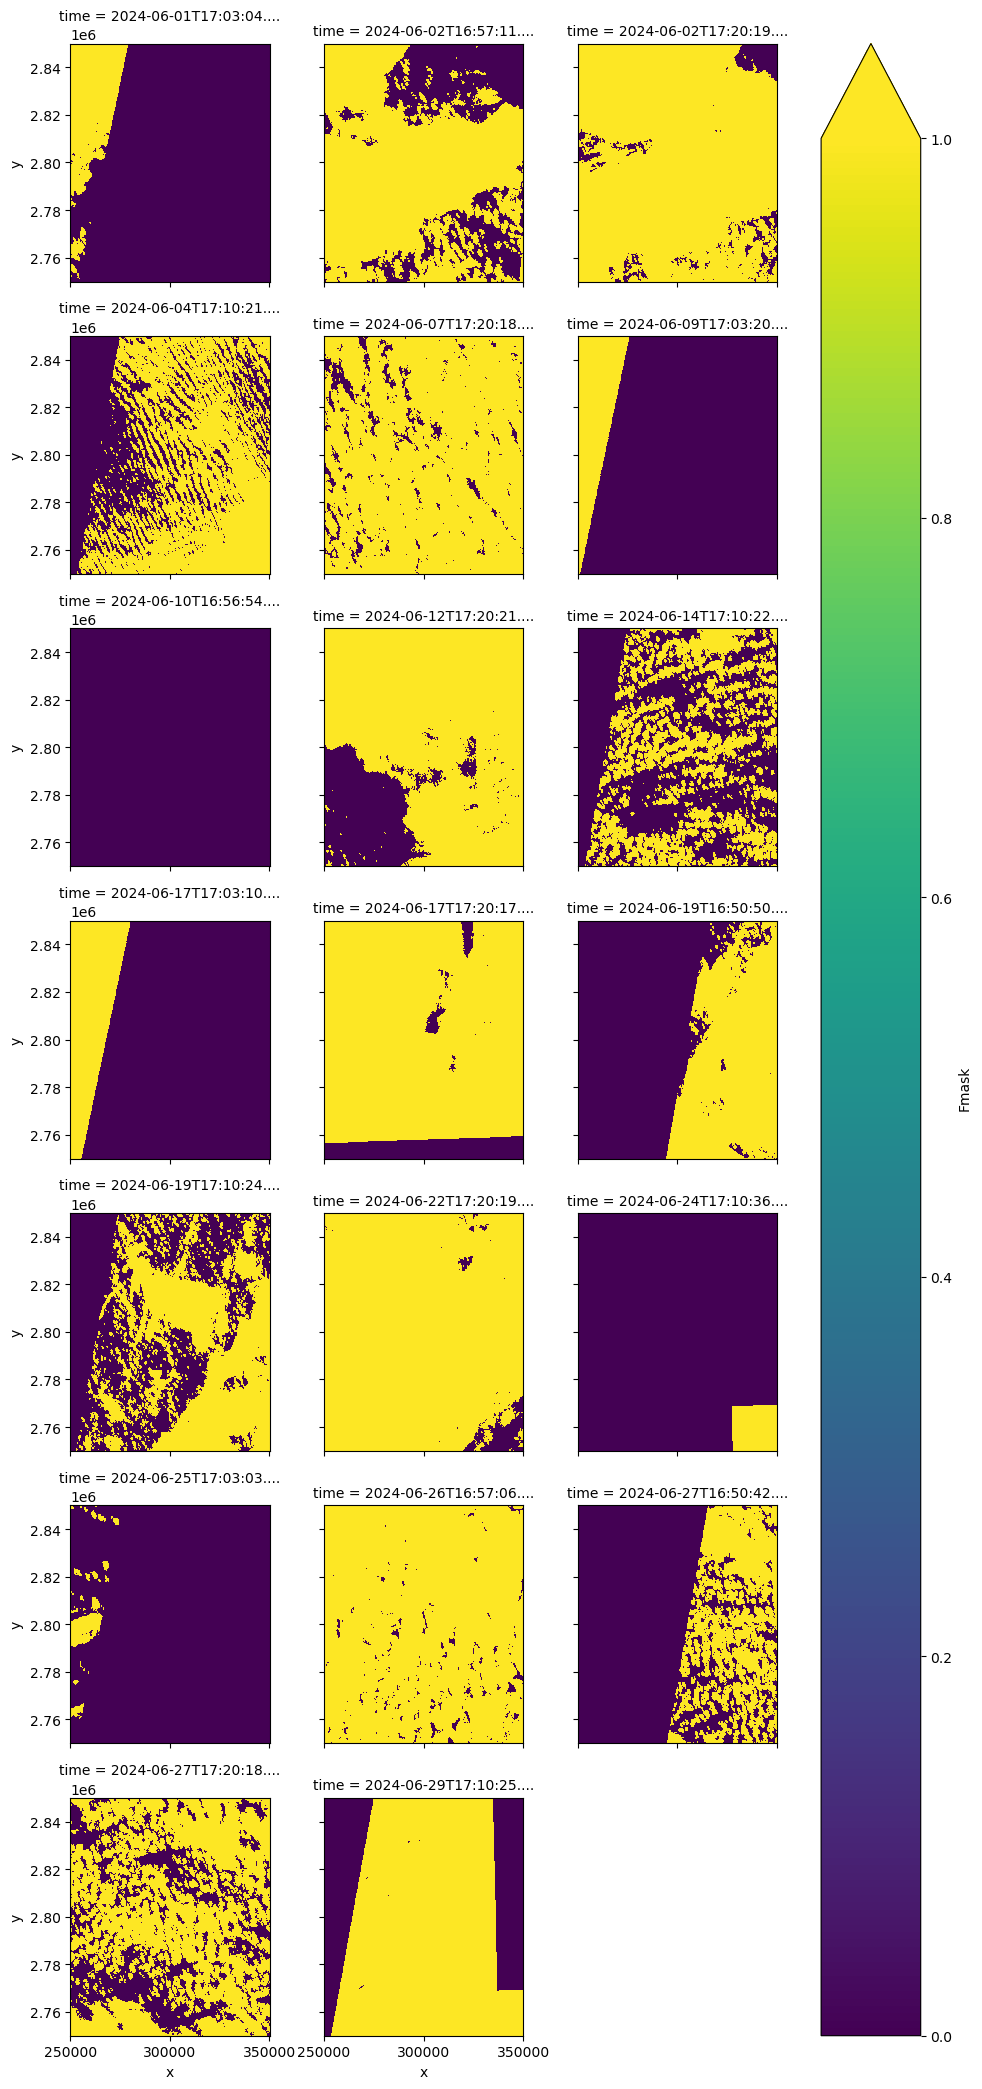

In [13]:
fmask = stack["Fmask"].astype("uint16")
mask = fmask & hls_bitmask

(
    mask.sel(
        time=slice("2024-06-01", "2024-06-30"),
    ).plot.imshow(
        col="time",
        col_wrap=3,
        vmin=0,
        vmax=1,
        cmap="viridis",
    )
)

In [20]:
cloud_free = stack.where(mask == 0).where(stack != -9999)

monthly_cloud_free = cloud_free.resample(time="1M").median(skipna=True)
monthly_cloud_free

<xarray.Dataset> Size: 86MB
Dimensions:      (time: 12, y: 667, x: 668)
Coordinates:
  * y            (y) float64 5kB 2.85e+06 2.85e+06 ... 2.75e+06 2.75e+06
  * x            (x) float64 5kB 2.5e+05 2.501e+05 ... 3.499e+05 3.5e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 96B 2024-01-31 2024-02-29 ... 2024-12-31
Data variables:
    red          (time, y, x) float32 21MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>
    green        (time, y, x) float32 21MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>
    blue         (time, y, x) float32 21MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>
    Fmask        (time, y, x) float32 21MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>

In [21]:
%%time
monthly_cloud_free.load()

CPU times: user 1min 59s, sys: 11.4 s, total: 2min 11s
Wall time: 3min 56s


<xarray.Dataset> Size: 86MB
Dimensions:      (time: 12, y: 667, x: 668)
Coordinates:
  * y            (y) float64 5kB 2.85e+06 2.85e+06 ... 2.75e+06 2.75e+06
  * x            (x) float64 5kB 2.5e+05 2.501e+05 ... 3.499e+05 3.5e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 96B 2024-01-31 2024-02-29 ... 2024-12-31
Data variables:
    red          (time, y, x) float32 21MB 228.0 979.0 4.89e+03 ... -7.0 164.0
    green        (time, y, x) float32 21MB 101.0 1.074e+03 ... 5.0 233.0
    blue         (time, y, x) float32 21MB 66.0 921.0 3.709e+03 ... -109.0 57.0
    Fmask        (time, y, x) float32 21MB 104.0 104.0 104.0 ... 0.0 0.0 0.0

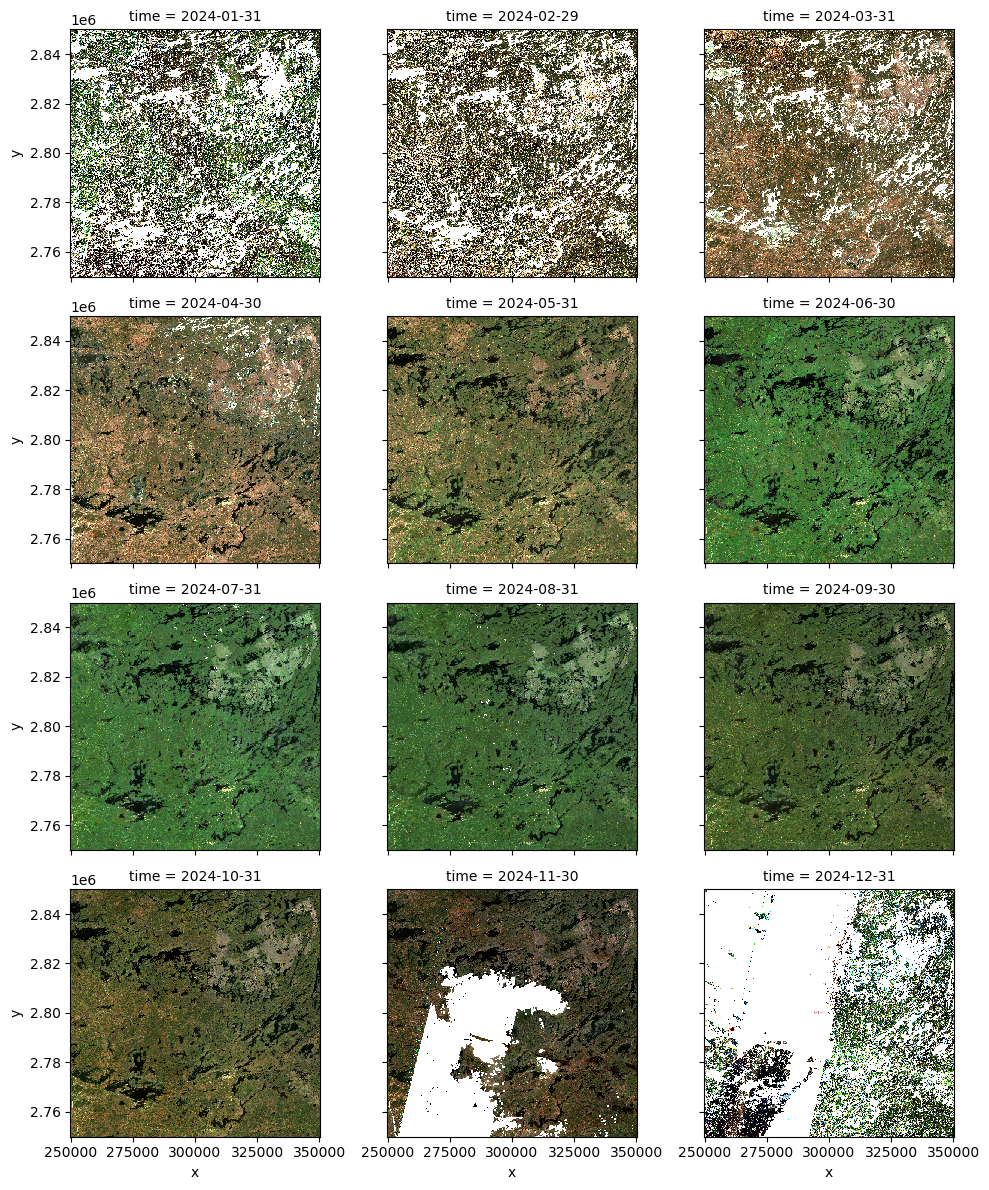

In [22]:
(
    monthly_cloud_free.to_dataarray(dim="band").sel(
        band=["red", "green", "blue"]
    ).plot.imshow(
        rgb="band",
        col="time",
        col_wrap=3,
        robust=True,
        vmin=0,
        vmax=1000,
    )
)